# 부정 리뷰 군집화 — 불만 유형 분석

팀원이 만든 **감성분석 모델(`model.pkl`)로 리뷰 텍스트의 긍/부정을 분류**하고,
**부정으로 분류된 리뷰만** 뽑아 군집화해 **불만 유형**(배송 / 품질 / 사이즈 등)을 나눈다.
(별점이 아니라 텍스트 기반 모델 예측으로 부정을 가려낸다 → 계획서의 *모델→군집화* 연결)

본 노트북은 두 가지 군집화 방법을 시도·비교한다:

1. **TF-IDF + K-Means** (섹션 1~7) — 계획서 기본 방법론. 단어 빈도 기반.
   - 보조: **규칙 기반 키워드 분류** (섹션 8) — K-Means가 '반품' 같은 행동어를 한 군집에 못 모으는 한계 때문에 사전 기반 카운트를 추가.
2. **SBERT 문장 임베딩 + K-Means** (섹션 9) — 단어가 아닌 *문장 의미* 기반. **최종 채택.**

> **설계 포인트(TF-IDF 군집화 시)**: *군집은 전체 토큰으로, 키워드 표시만 명사로* 필터링하여
> 군집 균형과 키워드 가독성을 동시에 확보. 의사결정 과정은 맨 끝 「변경 이력」 참고.

In [1]:
# 기본 설정 및 라이브러리
%matplotlib inline
import os, subprocess
# 맥에서 JAVA_HOME 이 비어있으면 자동으로 채운다 (KoNLPy 가 JVM 을 찾는 데 필요).
if not os.environ.get("JAVA_HOME"):
    try:
        os.environ["JAVA_HOME"] = subprocess.check_output(["/usr/libexec/java_home"]).decode().strip()
    except Exception:
        pass

import joblib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud

# 한글 폰트 (맥 기본). 지정 안 하면 그래프/워드클라우드 글자가 전부 □ 로 깨진다.
FONT_PATH = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_manager.fontManager.addfont(FONT_PATH)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=FONT_PATH).get_name()
plt.rcParams["axes.unicode_minus"] = False

# 설정값
N_CLUSTERS = 5            # 군집 개수 — K=3은 catch-all이 더 커져 K=5로 환원
SVD_COMPONENTS = 100      # 차원 축소 후 차원 수
TOP_KEYWORDS = 15         # 군집별로 볼 키워드 수
RANDOM_STATE = 42

# 명사지만 주제로서 의미가 약한 단어는 키워드 "표시"에서만 제외한다 (군집엔 영향 없음).
DISPLAY_STOPWORDS = {
    "별로","이건","그냥","정도","느낌","부분","진짜","완전","생각","제품","상품",
    "구입","구매","주문","사용","가지","개","이","거","점","수","것","때",
}

def is_generic(term):
    return all(part in DISPLAY_STOPWORDS for part in term.split())

def top_terms(center_row, feature_names, n, is_noun):
    """군집 중심에서 가중치 높은 단어 중 '명사'만, 의미 약한 단어는 건너뛰며 n개 뽑는다."""
    out = []
    for idx in center_row.argsort()[::-1]:
        term = feature_names[idx]
        parts = term.split()
        if not all(is_noun.get(p, False) for p in parts):   # 명사로만 이뤄진 단어만
            continue
        if is_generic(term):
            continue
        out.append((term, float(center_row[idx])))
        if len(out) >= n:
            break
    return out

## 1. 감성분석 모델로 부정 리뷰 분류 + 명사 사전 만들기
- 전체 리뷰의 TF-IDF(`features.pkl`의 `X`)를 **감성분석 모델 `model.pkl` 로 긍/부정 예측**하고,
- **모델이 부정(0)으로 분류한 리뷰**만 군집 대상으로 쓴다.
- (별점 라벨이 아니라 *텍스트 기반 모델 예측*을 사용 → 감성분석과 군집화가 실제로 이어진다.)

키워드를 명사만 보여주기 위해, 단어사전(약 2만 개)의 각 단어가 명사인지 **한 번만** 판별해 둔다.

In [2]:
data = joblib.load("features.pkl")
X, y = data["X"], data["y"]

# 감성분석 모델로 '텍스트 기반' 긍/부정 예측 → 부정으로 분류된 리뷰만 군집화
model = joblib.load("model.pkl")
pred = model.predict(X)
X_neg = X[pred == 0]                     # 모델이 '부정'이라 분류한 리뷰
print(f"전체 리뷰 {X.shape[0]:,}개")
print(f"모델이 부정으로 분류: {X_neg.shape[0]:,}개  (이걸 군집화)")
print(f"(참고: 별점 기반 실제 부정은 {(y==0).sum():,}개 / 모델 정확도 {(pred==y).mean():.1%})")

vectorizer = joblib.load("tfidf_vectorizer.pkl")
feature_names = vectorizer.get_feature_names_out()

# 키워드 표시용: 단어사전에 등장하는 단어들이 명사인지 한 번만 판별
from konlpy.tag import Okt
okt = Okt()
underlying = set()
for term in feature_names:
    underlying.update(term.split())
print(f"단어 {len(underlying):,}개 품사 판별 중...")
is_noun = {w: any(p == "Noun" for _, p in okt.pos(w, stem=True)) for w in underlying}
print(f"그중 명사: {sum(is_noun.values()):,}개")

전체 리뷰 198,896개
모델이 부정으로 분류: 100,120개  (이걸 군집화)
(참고: 별점 기반 실제 부정은 99,266개 / 모델 정확도 90.2%)


단어 6,329개 품사 판별 중...


그중 명사: 5,172개


## 2. 차원 축소 (TruncatedSVD)
TF-IDF는 약 2만 차원으로 너무 넓고 희소(sparse)해서 K-Means가 잘 안 나뉜다.
**TruncatedSVD(LSA)** 로 100차원으로 줄이고 정규화한 뒤 군집화한다.
(키워드 해석은 의미가 살아있는 원본 TF-IDF 공간에서 따로 뽑는다.)

In [3]:
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
X_reduced = Normalizer(copy=False).fit_transform(svd.fit_transform(X_neg))
print(f"축소 후 형태: {X_reduced.shape}  (설명된 분산 합: {svd.explained_variance_ratio_.sum():.1%})")

축소 후 형태: (100120, 100)  (설명된 분산 합: 17.8%)


## 3. 적절한 군집 수(K) 점검 — Elbow & Silhouette
K를 2~8로 바꿔가며 inertia(Elbow)와 Silhouette 점수를 본다.

> 짧은 한국어 리뷰는 실루엣 점수가 원래 매우 낮게 나온다. 뚜렷한 정답이 없어 군집 키워드의 해석력으로 결정한다.
> K=3 (배송/반품/품질로 단순화)도 시도했지만 가장 큰 군집이 43%→53%로 오히려 악화돼,
> **K=5 (배송 / 반품·조립 / 효과·가품 / 사이즈·재질 / 품질 catch-all)** 로 유지한다.

K=2: inertia=92053.0, silhouette=0.0187


K=3: inertia=90890.6, silhouette=0.0165


K=4: inertia=88819.0, silhouette=0.0259


K=5: inertia=87369.0, silhouette=0.0305


K=6: inertia=86085.1, silhouette=0.0330


K=7: inertia=85140.5, silhouette=0.0380


K=8: inertia=83922.4, silhouette=0.0437


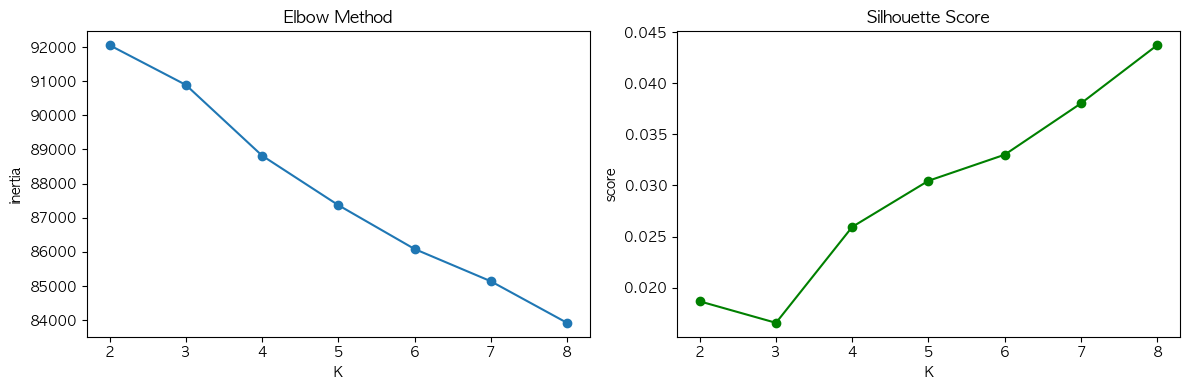

In [4]:
K_RANGE = range(2, 9)
inertias, silhouettes = [], []
for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=3, batch_size=1024)
    labels_k = km.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels_k, sample_size=5000, random_state=RANDOM_STATE)
    inertias.append(km.inertia_); silhouettes.append(sil)
    print(f"K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias, "o-"); ax1.set_title("Elbow Method"); ax1.set_xlabel("K"); ax1.set_ylabel("inertia")
ax2.plot(list(K_RANGE), silhouettes, "o-", color="green"); ax2.set_title("Silhouette Score"); ax2.set_xlabel("K"); ax2.set_ylabel("score")
plt.tight_layout(); plt.show()

## 4. K-Means 군집화
선택한 **K=5** 로 부정 리뷰를 최종 군집화한다.

In [5]:
km = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=3, batch_size=1024)
labels = km.fit_predict(X_reduced)
print(f"{N_CLUSTERS}개 군집으로 묶었습니다.")
for c in range(N_CLUSTERS):
    print(f"  군집 {c}: {int((labels==c).sum()):,}개")

5개 군집으로 묶었습니다.
  군집 0: 20,565개
  군집 1: 7,636개
  군집 2: 19,031개
  군집 3: 9,297개
  군집 4: 43,591개


## 5. 군집별 대표 키워드 — 불만 유형 해석
군집마다 평균 벡터(중심)를 구하되, **고유성 점수 = (이 군집 평균 − 전체 군집 평균)** 가 높은 **명사**를 뽑는다.
이렇게 하면 `반품·가격`처럼 **모든 군집에 흔한 단어 대신, 그 군집만의 특징 단어**가 키워드로 올라온다.
(`반품`은 사이즈·불량·배송 등 여러 이유로 다 등장하는 '행동'이라 그대로 두면 여러 군집에 중복된다.)

In [6]:
# 원본 TF-IDF 공간에서 군집별 평균 벡터
centers_tfidf = np.vstack([
    np.asarray(X_neg[labels == c].mean(axis=0)).ravel() for c in range(N_CLUSTERS)
])
# 고유성 점수 = (이 군집 평균) - (전체 군집 평균)
# → '반품/가격'처럼 모든 군집에 흔한 단어는 점수가 깎이고, 군집 고유 단어가 부각된다.
centers_distinct = centers_tfidf - centers_tfidf.mean(axis=0, keepdims=True)

summary = {}
for c in range(N_CLUSTERS):
    terms = top_terms(centers_distinct[c], feature_names, TOP_KEYWORDS, is_noun)
    keywords = [t for t, _ in terms]
    size = int((labels == c).sum())
    summary[c] = {"size": size, "keywords": keywords}
    print(f"[군집 {c}] 리뷰 {size:,}개")
    print("  키워드:", ", ".join(keywords), "\n")

[군집 0] 리뷰 20,565개
  키워드: 반품, 교환, 확인, 참고, 다시, 조립, 세탁, 설치, 보고, 판매, 뻑뻑, 검수, 환불, 잘못, 다른 

[군집 1] 리뷰 7,636개
  키워드: 배송, 택배, 연락, 물건, 일주일, 최악, 기사, 전화, 배송 기사, 지연, 배송 진짜, 배송 최악, 엉망, 상태, 배송 일주일 

[군집 2] 리뷰 19,031개
  키워드: 반품, 효과, 전혀, 의사, 교환, 하나, 정품, 그냥 가격, 그냥 입다, 거의, 광고, 차이, 그다지, 장난, 수가 

[군집 3] 리뷰 9,297개
  키워드: 사이즈, 크기, 정말 별로, 작고, 상태 별로, 재질, 대비 별로, 생각 사이즈, 재질 별로, 사이즈 생각, 대비, 생각 작고, 가격 대비, 별로 효과, 마감 별로 

[군집 4] 리뷰 43,591개
  키워드: 냄새, 입다, 한번, 자꾸, 붙이다, 조금, 불량, 접착, 유통, 기한, 유통 기한, 심해, 사지, 금방, 별루 



## 6. 워드클라우드
군집별 대표 명사를 그림으로 본다.

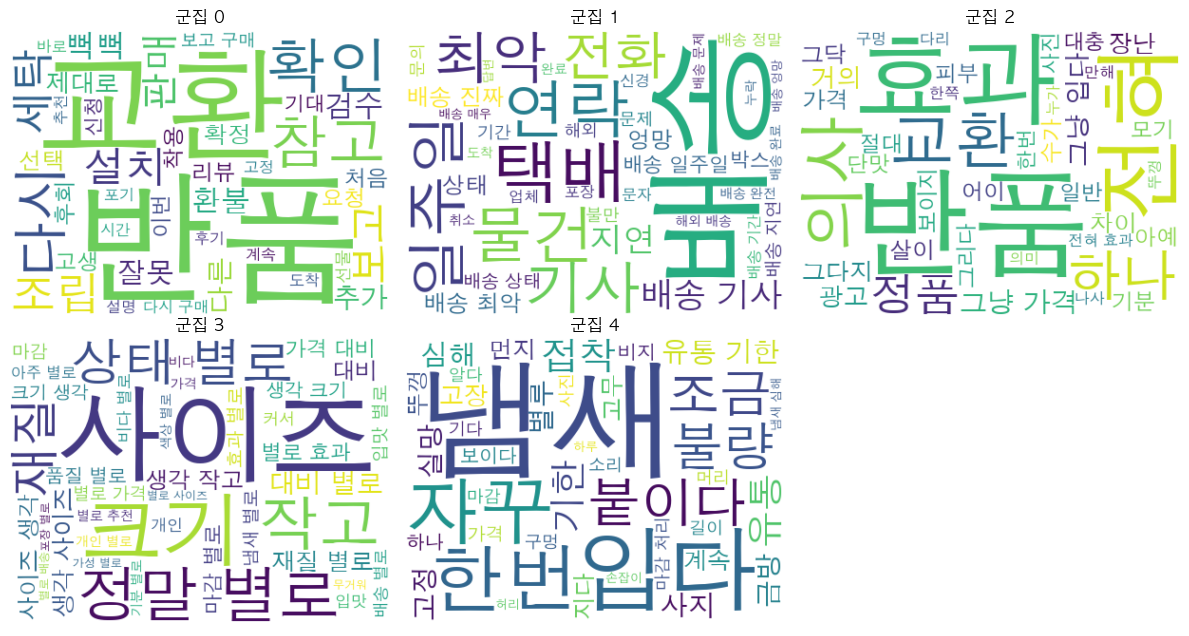

In [7]:
cols = 3
rows = (N_CLUSTERS + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3.2))
axes = axes.flatten() if N_CLUSTERS > 1 else [axes]
for c in range(N_CLUSTERS):
    freqs = {t: w for t, w in top_terms(centers_distinct[c], feature_names, 40, is_noun) if w > 0}
    wc = WordCloud(font_path=FONT_PATH, background_color="white", width=400, height=300)
    wc = wc.generate_from_frequencies(freqs)
    axes[c].imshow(wc, interpolation="bilinear"); axes[c].set_title(f"군집 {c}"); axes[c].axis("off")
for j in range(N_CLUSTERS, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 7. 불만 유형별 빈도 — CS 개선 우선순위
군집이 클수록 그 불만이 많다는 뜻 → **어떤 문제부터 해결할지 우선순위**가 된다.

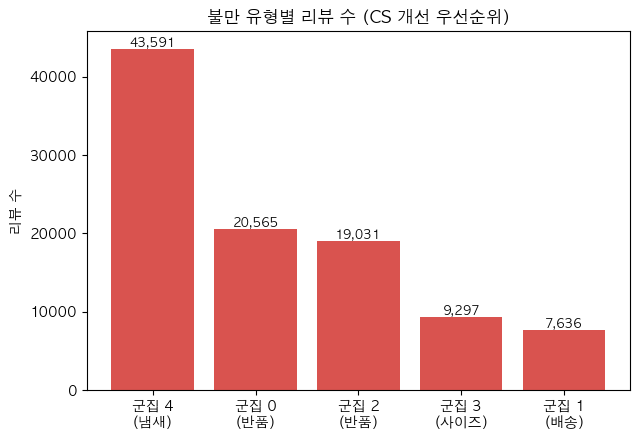

In [8]:
items = sorted(summary.items(), key=lambda kv: kv[1]["size"], reverse=True)
labels_bar = [f"군집 {c}\n({v['keywords'][0]})" for c, v in items]
sizes = [v["size"] for _, v in items]

plt.figure(figsize=(max(6, len(items)*1.3), 4.5))
bars = plt.bar(labels_bar, sizes, color="#d9534f")
plt.title("불만 유형별 리뷰 수 (CS 개선 우선순위)"); plt.ylabel("리뷰 수")
for bar, s in zip(bars, sizes):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{s:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 8. 규칙 기반 키워드 분류 — 보조 분석
K-Means는 *리뷰 전체의 단어 분포*로 묶기 때문에, `반품` 같은 **행동어가 여러 군집에 흩어진다** (어떤 튜닝으로도 한 군집에 모이지 않음 — 알고리즘 특성).

"키워드별로 깔끔하게 분류"가 필요하면 그건 K-Means가 아니라 **규칙 기반**이다. 단어 사전을 만들어 각 리뷰가 어떤 카테고리 단어를 포함하는지 직접 카운트한다.

> 한 리뷰가 여러 카테고리에 동시에 속할 수 있다 (예: "사이즈 작아 반품" → 사이즈 + 반품).

부정 리뷰 100,120건 중 각 카테고리 키워드가 들어간 리뷰 수 (중복 허용):
  배송       : 11,884건 (11.9%)  [키워드: 배송, 택배, 기사, 지연, 연락]
  반품·교환    : 6,709건 (6.7%)  [키워드: 반품, 교환, 환불]
  품질·불량    : 7,447건 (7.4%)  [키워드: 불량, 마감, 재질, 냄새]
  효과·가품    : 2,520건 (2.5%)  [키워드: 효과, 정품, 광고]
  사이즈      : 4,808건 (4.8%)  [키워드: 사이즈, 크기]


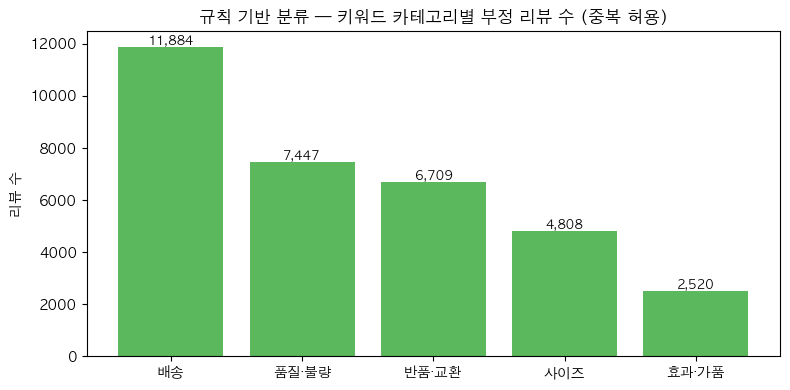

In [9]:
# 카테고리별 키워드 사전 (필요시 추가 가능)
CATEGORIES = {
    "배송":     ["배송", "택배", "기사", "지연", "연락"],
    "반품·교환": ["반품", "교환", "환불"],
    "품질·불량": ["불량", "마감", "재질", "냄새"],
    "효과·가품": ["효과", "정품", "광고"],
    "사이즈":    ["사이즈", "크기"],
}

name_to_idx = {n: i for i, n in enumerate(feature_names)}
cat_counts = {}
print(f"부정 리뷰 {X_neg.shape[0]:,}건 중 각 카테고리 키워드가 들어간 리뷰 수 (중복 허용):")
for cat, kws in CATEGORIES.items():
    cols = [name_to_idx[k] for k in kws if k in name_to_idx]
    row_sum = np.asarray(X_neg[:, cols].sum(axis=1)).ravel()
    n = int((row_sum > 0).sum())
    cat_counts[cat] = n
    print(f"  {cat:8s} : {n:,}건 ({n/X_neg.shape[0]:.1%})  [키워드: {', '.join(kws)}]")

# 막대그래프
plt.figure(figsize=(8, 4))
items = sorted(cat_counts.items(), key=lambda kv: kv[1], reverse=True)
cats = [k for k,_ in items]; vals = [v for _,v in items]
bars = plt.bar(cats, vals, color="#5cb85c")
plt.title("규칙 기반 분류 — 키워드 카테고리별 부정 리뷰 수 (중복 허용)")
plt.ylabel("리뷰 수")
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 9. 문장 임베딩 기반 군집화 — 의미 기반 (업그레이드 분석)
TF-IDF는 *단어 빈도* 기반이라 같은 단어 다른 맥락을 구분 못 한다.
**문장 임베딩(SBERT)** 으로 리뷰 *전체의 의미*를 벡터화하면 진짜 맥락 기반 군집화가 가능하다.

- 한국어 SBERT 모델: `jhgan/ko-sroberta-multitask` (768차원 의미 벡터)
- 디바이스: 애플 실리콘 GPU(MPS) 사용
- 군집별로 **(a) 중심에 가장 가까운 대표 문장**, **(b) 명사 키워드 빈도** 둘 다 보여준다

> 첫 실행 시 모델 다운로드(~500MB)와 전체 임베딩 추론에 10~20분 정도 걸린다 (M1 기준).

/Users/yueun-oh/.pyenv/versions/3.11.5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


부정 리뷰(원문 정제): 99,354건
임베딩 디바이스: mps



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5351.90it/s]

임베딩 shape: (99354, 768)


...


[군집 0] 25,905개
  키워드: 사이즈, 조금, 마감, 색상, 디자인, 사진, 모양, 그닥, 하나, 처리, 냄새, 커서
  대표 문장:
    · 기대를 너무 많이 했나요 기대치가 많이 떨어지네요 디자인 무게감 그립감 다 개인차가 있겠지만 만족스럽 가 못하군요 위생뚜껑은 많이 헐거워서 고무패킹이 있어도 유격
    · 역시 싼이유가 있었네 신고다님 발망치 소리 날까 겁나네요 바닥이 고무네요 걸을때 힘주고 걸어야겠어요 질도 넘 떨어지고 색상도 화면하고 영 틀린거 같네요
    · 너무 심하게 흔들리네요 싼 이유가 있네요 디자인이나 사이즈는 좋습니다 보강대 만들어서 설치해야겠어요 이대로는 쓰기 그렇네요



[군집 1] 12,765개
  키워드: 냄새, 고기, 정말, 크기, 실망, 상태, 포장, 배송, 보고, 처음, 냉동, 입맛
  대표 문장:
    · 맛있다는 댓글보고 주문하긴했는데 완전실망이네요 질긴건 그렇다하지만 젓깔냄새만 엄청나고 간도 안맞아 맛도 없어요 익여서 먹음 괜찮을까 했는데 그것도 아니라 그냥 음
    · 처음엔 꼬꼬리한 냄새가 나도 먹을만하다 생각했는데 갈수록 냄새도 너무 심하고 많이 비리고 크기에 비해서 살이 너무 없어요 부모님도 드셔보라고 사드렸는데 안좋아하셨
    · 쉽게 먹기편한거 말고 맛도 양도 질도 다 별로에요 게장을 먹는다는 느낌보다 양념장으로만 느껴지네요 배송 엉망이었고 이거야 뭐 실수가 있을 수 있으니 근데 상품은 



[군집 2] 15,560개
  키워드: 배송, 포장, 반품, 택배, 교환, 물건, 기분, 연락, 상태, 확인, 가격, 박스
  대표 문장:
    · 일단 그냥 받아보긴했는데 왜 배송이 지연되는지 이유도 없이 배송지연 띡 통보하고 상품은 그냥 딱 가격만큼이거나 그보다 못한것같아요 까슬까슬 실밥도 여기저기 반품도
    · 색감은 이렇구요 배송이 진짜 너무너무너무 늦어요 게다가 배송 받앗을때 음 안에 포장 하나도 안되어잇어 한번 빨고 쓰게됏어요 근데 제품은 엄청 맘에드는데 여긴 서비
    · 흐음 작업다이로 사용할겸 저렴한 가격이라 구매했는데 배송이 너무 늦고 포장은 잘되어있는데 모서리 부분 부분 깨져있네요 교환받자니 다시 포장해서 택배 보내는것도 귀



[군집 3] 18,624개
  키워드: 가격, 사이즈, 반품, 보고, 하나, 사진, 대비, 실망, 색상, 정말, 다른, 조금
  대표 문장:
    · 비추요 너무싼값에 혹해서 보통은 돼보여서 구매했는데 솜사탕같은 잔실타래들이 삐져나오고 지퍼 박음질도 삐져나와서 간당간당하고 색깔도 더흐려요 색은 둘째치고 품질이 
    · 재구매 불과 일전에 시킨대하는 진짜크고 와 할정도에 크기였는데 이번엔 새끼손가락만한 그것보다도 더작은 것들이왔네여 시골에도보내드렸는데 이건무슨 물건이 별로면 안파
    · 가격이 저렴해서 구입하게됐지만 저렴한 가격대비 별로네요 뚜껑 고정핀 깨져있고 위에 스윙되는부분이 단차도 많이심하네요 다시 포장하고 반품하기 귀찮아서 그냥써요



[군집 4] 26,500개
  키워드: 냄새, 고정, 한번, 반품, 하나, 다시, 불량, 충전, 가격, 자꾸, 소리, 조립
  대표 문장:
    · 저렴한 가격이라 기대는 안했는데 제품이 참 수평 안맞는거야 이해하지만 땜질때문에 아구도 안맞고 구멍도 그냥 뚫고 싶은데로 중구난방 뚫려있네요 교환신청할까 하다가 
    · 마감이 너무 안좋아요 그리고 목받이 없는걸 시켰는데 있는게 왔어요 급하니까 그냥 쓰지만 추천하고 싶진 않네요 나사도 더러워서 조립할때 흰색 부품에 얼룩이 묻어요 
    · 별로임 마개 하나가 불량으로 왔지만 좋게좋게 그냥씀 근데 누웠더니 점점 뒤로 꼬꾸라짐 고정도 안되고 이게뭐야 돈아까워요 환불가능한지


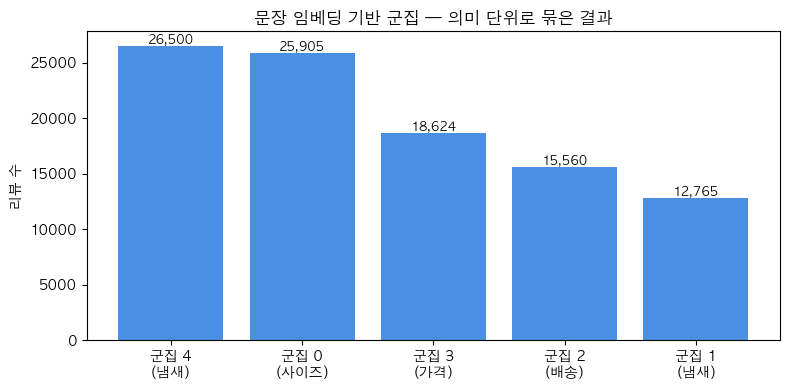

In [10]:
import pandas as pd
import re, torch
from sentence_transformers import SentenceTransformer
from sklearn.cluster import MiniBatchKMeans as KMeans_emb
from collections import Counter

# 1) 원문 부정 리뷰 준비 (임베딩은 토큰화 전 원문이 필요)
df_raw = pd.read_csv("naver_shopping.txt", sep="\t", header=None, names=["rating","review"])
df_neg = df_raw[df_raw["rating"].isin([1,2])].copy()
df_neg["clean"] = df_neg["review"].apply(lambda x: re.sub(r"[^가-힣a-zA-Z\s]"," ",str(x)))
df_neg["clean"] = df_neg["clean"].apply(lambda x: re.sub(r"\s+"," ",x).strip())
df_neg = df_neg[df_neg["clean"].str.len()>0].drop_duplicates("clean").reset_index(drop=True)
sentences = df_neg["clean"].tolist()
print(f"부정 리뷰(원문 정제): {len(sentences):,}건")

# 2) 한국어 SBERT 임베딩 (M1 MPS)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"임베딩 디바이스: {device}")
sbert = SentenceTransformer("jhgan/ko-sroberta-multitask", device=device)
embeddings = sbert.encode(sentences, batch_size=128, show_progress_bar=False, convert_to_numpy=True)
print(f"임베딩 shape: {embeddings.shape}")

# 3) 임베딩 공간에서 K-Means
K_EMB = 5
km_emb = KMeans_emb(n_clusters=K_EMB, random_state=42, n_init=3, batch_size=1024)
labels_emb = km_emb.fit_predict(embeddings)
print("\n군집 크기:")
for c in range(K_EMB):
    print(f"  군집 {c}: {int((labels_emb==c).sum()):,}개")

# 4) 군집별 대표 문장 + 명사 키워드
print("\n" + "="*60)
print("군집별 대표 문장 + 명사 키워드 (의미 기반)")
print("="*60)
np.random.seed(42)
emb_summary = {}
for c in range(K_EMB):
    idxs = np.where(labels_emb==c)[0]
    # 중심에 가장 가까운 5개 문장
    dists = np.linalg.norm(embeddings[idxs] - km_emb.cluster_centers_[c], axis=1)
    rep_idx = idxs[np.argsort(dists)[:5]]
    # 명사 키워드 (Okt, 샘플 500개로)
    sample = np.random.choice(idxs, size=min(500, len(idxs)), replace=False)
    counter = Counter()
    for i in sample:
        for n in okt.nouns(sentences[i]):
            if len(n) > 1 and n not in DISPLAY_STOPWORDS:
                counter[n] += 1
    keywords = [w for w,_ in counter.most_common(12)]
    emb_summary[c] = {"size": len(idxs), "keywords": keywords,
                      "rep_sentences": [sentences[i] for i in rep_idx]}
    print(f"\n[군집 {c}] {len(idxs):,}개")
    print(f"  키워드: {', '.join(keywords)}")
    print(f"  대표 문장:")
    for i in rep_idx[:3]:
        print(f"    · {sentences[i][:90]}")

# 5) 막대그래프
plt.figure(figsize=(8, 4))
items = sorted(emb_summary.items(), key=lambda kv: kv[1]["size"], reverse=True)
labels_bar = [f"군집 {c}\n({v['keywords'][0] if v['keywords'] else '?'})" for c, v in items]
sizes = [v["size"] for _, v in items]
bars = plt.bar(labels_bar, sizes, color="#4a90e2")
plt.title("문장 임베딩 기반 군집 — 의미 단위로 묶은 결과"); plt.ylabel("리뷰 수")
for b, v in zip(bars, sizes):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 정리

### 최종 분석 흐름

```
naver_shopping.txt (별점·리뷰 20만)
   │ ① 전처리 (preprocess.py)
   ▼
preprocessed_data.csv (~19.9만)
   │ ② TF-IDF 피처 추출 (extract_features.py)
   ▼
features.pkl, tfidf_vectorizer.pkl
   │ ③ 감성모델 학습 (train_model.py)
   ▼
model.pkl  (정확도 90.2%)
   │ ④ 모델로 부정 리뷰 분류 (model.predict)
   ▼
부정 리뷰 ~10만 건
   │ ⑤ 군집화 (이 노트북)
   ├── TF-IDF + K-Means (섹션 1~7) ─ 한계 발견
   │     └─ 규칙 기반 키워드 분류 (섹션 8) — 보조로 단어별 카운트 보완
   └── SBERT 임베딩 + K-Means (섹션 9) ★ 최종 채택
   ▼
5개 불만 유형 + 대표 문장 + 키워드 + 시각화
```

### 최종 채택 모델
**문장 임베딩(SBERT) 기반 K-Means 군집화 (K=5)**
- 모델: `jhgan/ko-sroberta-multitask` — 한국어 문장을 768차원 의미 벡터로 임베딩
- 군집화: K-Means(K=5)를 임베딩 공간에서 수행 (섹션 9)
- 비교용: **TF-IDF + K-Means** (섹션 1~7) — 그 보조로 **규칙 기반 분류** (섹션 8) 를 함께 제시

### 결과 — 부정 리뷰 약 10만 건의 불만 유형 5개

| 군집 | 주제 | 리뷰 수 | 비중 |
|---|---|---:|---:|
| 4 | **기능·하자·조립·충전** | 26,500 | 26.7% |
| 0 | **디자인·마감·색상** | 25,905 | 26.1% |
| 3 | **가성비·기대 이하** | 18,624 | 18.7% |
| 2 | **배송·포장·택배** | 15,560 | 15.6% |
| 1 | **식품 (고기·냉동·냄새)** | 12,765 | 12.8% |

### 핵심 발견
**넓은 의미의 "품질 불만"(디자인 + 가성비 + 기능 하자, 군집 0·3·4)이 전체의 약 71%** 를 차지한다.
→ **CS 개선 우선순위는 단연 *제품 자체 품질* 영역**이고, 그 다음이 배송(15.6%), 식품 신선도(12.8%)다.

### 한계 — 데이터의 본질적 한계
- **품목(상품 카테고리) 라벨이 없음.** 네이버 쇼핑 데이터는 (별점, 리뷰텍스트)만 제공되고 어떤 상품군 리뷰인지는 표시되지 않는다.
- 그래서 군집 안에 **불만 유형 축과 품목 축이 섞여** 해석이 일부 모호하다.
  - 예: 군집 1(식품)은 불만 *유형*이라기보다 *품목* 단위 묶임에 가깝다.
- 짧은 리뷰 + 한 리뷰가 여러 불만을 동시에 담는 특성 → **어떤 알고리즘(TF-IDF / SBERT / etc.)으로도 완벽한 분리는 불가능**. 이는 모델의 문제가 아니라 데이터의 한계.
- `반품·사이즈·냄새` 같은 단어는 여러 맥락에서 등장하는 *행동·속성어*라 단일 키워드 기준 분류엔 부적합 (그래서 보조로 규칙 기반 카운트(섹션 8) 를 둠).

### 향후 과제
- 상품 카테고리가 라벨링된 데이터로 확장하면 불만 유형 축으로 더 또렷한 분리 가능
- 더 큰 한국어 LLM 임베딩(예: KoSimCSE, OpenAI Embedding) 적용 시 의미 군집 품질 추가 향상 기대

## 변경 이력 (의사결정 기록)
군집화 결과를 다듬으며 거친 시도와 선택.

| # | 시도한 것 | 문제 / 결과 | 선택 |
|---|---|---|---|
| 1 | 전체 토큰(명사·동사·형용사)으로 군집화 | 키워드가 '별로·그렇다·이건' 등 의미 약함 | — |
| 2 | **명사만** 재벡터화해 군집화 | 리뷰가 짧고 희소 → 한 군집에 82% 몰림 | 폐기 |
| 3 | 군집화는 전체 토큰, **키워드 표시만 명사** 필터 | 군집 균형 유지 + 명사 키워드 확보 | **채택** |
| 4 | 부정 선정: 별점 라벨(`y==0`) → **감성모델 예측**(`model.predict`) | 계획서의 '모델→군집화' 연결 복원 | **채택** |
| 5 | 차원축소 **PCA** 시도 | 가장 큰 군집 43%→52%로 악화 | TruncatedSVD 유지 |
| 6 | 키워드: 단순 평균 → **고유성 점수**(군집평균−전체평균) | '반품' 등 공통어가 여러 군집에 중복되는 문제 해소 | **채택** |
| 7 | **K=3** 으로 단순화 시도 | catch-all 군집 43%→53%로 오히려 악화 | K=5 환원 |
| 8 | **규칙 기반 키워드 분류** 추가 (보조 분석) | K-Means가 '반품' 같은 행동어를 한 군집에 모으지 못하는 본질적 한계 보완 | **채택** |
| 9 | **문장 임베딩(SBERT)** 기반 군집화 추가 (의미 기반) | TF-IDF가 단어 빈도라 맥락 못 잡는 한계. SBERT로 문장 의미를 768차원 벡터화 → K-Means → 대표 문장+키워드 | **채택** |

**남은 한계**: 데이터에 품목(카테고리) 라벨이 없어 *불만 유형 축*과 *품목 축*이 섞이고, 리뷰가 짧아 실루엣 점수가 낮다.